# Импорты

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("mako")

# Загрузка данных

In [7]:
df = pd.read_csv('../data/raw/backrooms_survival_v4.csv')
df.T

,0,1,2,3,4,5,6,7,8,9,...,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
character_id,1,2,3,4,5,6,7,8,9,10,...,19991,19992,19993,19994,19995,19996,19997,19998,19999,20000
age,33,39,25,76,73,15,41,76,48,12,...,62,80,44,74,29,77,71,44,22,80
sex,female,female,female,male,male,female,female,male,female,male,...,male,male,male,male,male,male,female,female,male,male
height_cm,170,166,158,188,155,164,174,189,187,205,...,168,165,166,162,169,164,149,169,171,181
weight_kg,90,39,77,58,56,88,50,72,76,67,...,75,66,67,62,60,96,41,96,73,92
strength,6,2,3,5,5,4,3,1,5,3,...,5,3,4,2,4,0,4,2,3,1
reaction,5,3,3,5,4,5,4,3,5,5,...,5,5,5,6,3,3,4,6,3,3
stamina,5,4,4,6,3,7,6,1,4,7,...,5,3,4,4,4,2,4,2,3,3
speed,4,4,3,6,4,6,4,2,5,4,...,5,3,5,4,5,2,4,3,4,1
intelligence,6,5,2,3,5,4,3,6,5,4,...,3,4,5,7,3,4,3,8,4,2


# Общая информация

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
character_id,20000.0,10000.500000,5773.647028,1.0,5000.7500,10000.5000,15000.250,20000.0000
age,20000.0,46.006950,19.966162,12.0,29.0000,46.0000,63.000,80.0000
height_cm,20000.0,169.907650,11.931108,140.0,162.0000,170.0000,178.000,210.0000
weight_kg,20000.0,72.017200,15.756155,35.0,61.0000,72.0000,83.000,137.0000
strength,20000.0,3.790350,1.707701,0.0,3.0000,4.0000,5.000,10.0000
reaction,20000.0,4.705650,1.464211,0.0,4.0000,5.0000,6.000,10.0000
stamina,20000.0,4.417650,1.552172,0.0,3.0000,4.0000,5.000,10.0000
speed,20000.0,4.392400,1.534712,0.0,3.0000,4.0000,5.000,10.0000
intelligence,20000.0,5.101300,1.918990,0.0,4.0000,5.0000,7.000,10.0000
perception,20000.0,5.004350,1.547175,0.0,4.0000,5.0000,6.000,10.0000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   character_id                20000 non-null  int64  
 1   age                         20000 non-null  int64  
 2   sex                         20000 non-null  object 
 3   height_cm                   20000 non-null  int64  
 4   weight_kg                   20000 non-null  int64  
 5   strength                    20000 non-null  int64  
 6   reaction                    20000 non-null  int64  
 7   stamina                     20000 non-null  int64  
 8   speed                       20000 non-null  int64  
 9   intelligence                20000 non-null  int64  
 10  perception                  20000 non-null  int64  
 11  agility                     20000 non-null  int64  
 12  endurance                   20000 non-null  int64  
 13  stress_resistance           200

In [5]:
df.isnull().sum().sort_values(ascending=False)

character_id                  0
entity_density                0
has_first_aid_kit             0
medkit_count                  0
has_water                     0
water_amount                  0
has_food                      0
food_amount                   0
has_radio                     0
level_id                      0
level_difficulty              0
visibility                    0
entity_aggression             0
age                           0
resource_density              0
maze_complexity               0
geometry_stability            0
special_rule                  0
spawn_area_danger             0
distance_to_nearest_entity    0
noise_generated               0
time_since_last_encounter     0
survived_24h                  0
survival_time_hours           0
has_backpack                  0
has_knife                     0
flashlight_battery            0
has_flashlight                0
sex                           0
height_cm                     0
weight_kg                     0
strength

# Анализ таргетов

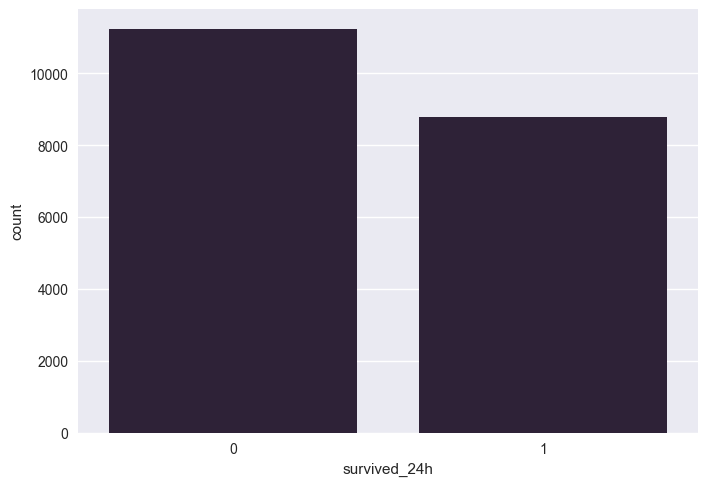

In [19]:
# sns.histplot(df['survived_24h'], kde=True)
sns.countplot(x='survived_24h', data=df)
plt.show()

In [7]:
df['survived_24h'].value_counts(normalize=True)

survived_24h
0    0.56125
1    0.43875
Name: proportion, dtype: float64

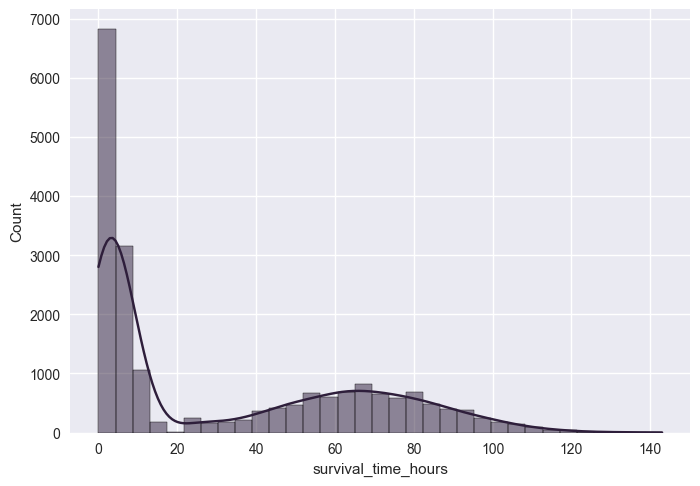

In [20]:
sns.histplot(df['survival_time_hours'], kde=True)
plt.show()

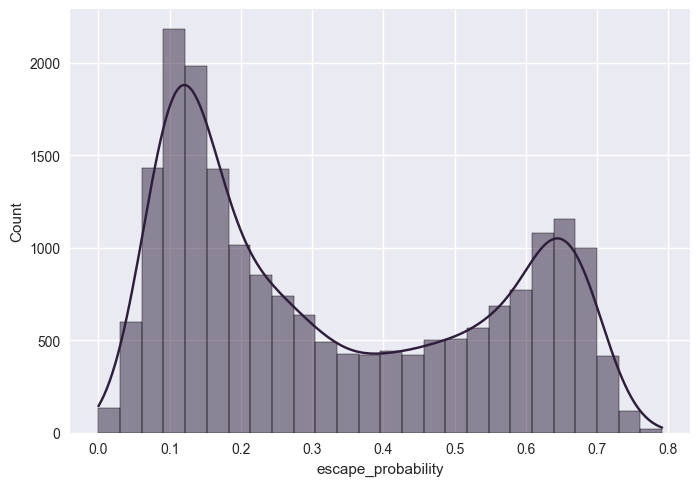

In [21]:
sns.histplot(df['escape_probability'], kde=True)
plt.show()

In [10]:
df.describe()

,character_id,age,height_cm,weight_kg,strength,reaction,stamina,speed,intelligence,perception,...,resource_density,maze_complexity,geometry_stability,spawn_area_danger,distance_to_nearest_entity,noise_generated,time_since_last_encounter,survived_24h,survival_time_hours,escape_probability
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,46.006950,169.907650,72.017200,3.790350,4.705650,4.417650,4.392400,5.10130,5.004350,...,41.596750,43.716150,37.811150,40.957450,33.61130,31.686200,12.031500,0.438750,31.555850,0.331386
std,5773.647028,19.966162,11.931108,15.756155,1.707701,1.464211,1.552172,1.534712,1.91899,1.547175,...,22.446597,22.081222,19.151037,19.428984,16.79084,16.034481,7.191432,0.496247,34.317871,0.221198
min,1.000000,12.000000,140.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,29.000000,162.000000,61.000000,3.000000,4.000000,3.000000,3.000000,4.00000,4.000000,...,25.000000,26.000000,23.000000,26.000000,21.00000,20.000000,6.000000,0.000000,3.000000,0.131300
50%,10000.500000,46.000000,170.000000,72.000000,4.000000,5.000000,4.000000,4.000000,5.00000,5.000000,...,39.000000,41.000000,36.000000,40.000000,35.00000,30.000000,12.000000,0.000000,9.000000,0.259200
75%,15000.250000,63.000000,178.000000,83.000000,5.000000,6.000000,5.000000,5.000000,7.00000,6.000000,...,55.000000,59.000000,51.000000,55.000000,46.00000,42.000000,18.000000,1.000000,63.000000,0.559000
max,20000.000000,80.000000,210.000000,137.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,...,100.000000,100.000000,100.000000,100.000000,89.00000,94.000000,24.000000,1.000000,143.000000,0.791500


In [11]:
df['escape_probability'].kurt()

np.float64(-1.3843560819220426)

# Анализ признаков + Выбросы + Пропуски

1. Закодировать категориальные признаки и повторно проанализировать хитмапу

In [12]:
numerical = df.select_dtypes(include=np.number).columns
categorical = df.select_dtypes(include='object').columns
df[categorical].value_counts()

sex     level_id  special_rule    
female  0         neutral             1250
male    0         neutral             1228
female  1         neutral             1166
male    1         neutral             1161
female  4         liminal_office      1124
male    4         liminal_office      1120
        3         mechanical_noise     970
        5         haunted_hotel        956
female  5         haunted_hotel        953
male    8         cave_isolation       947
female  8         cave_isolation       946
male    2         neutral              943
female  3         mechanical_noise     927
        2         neutral              905
        7         flooding             798
male    end       trap_exit            773
        6         darkness             769
        7         flooding             769
female  6         darkness             762
        end       trap_exit            742
other   3         mechanical_noise      98
        0         neutral               94
        2         n

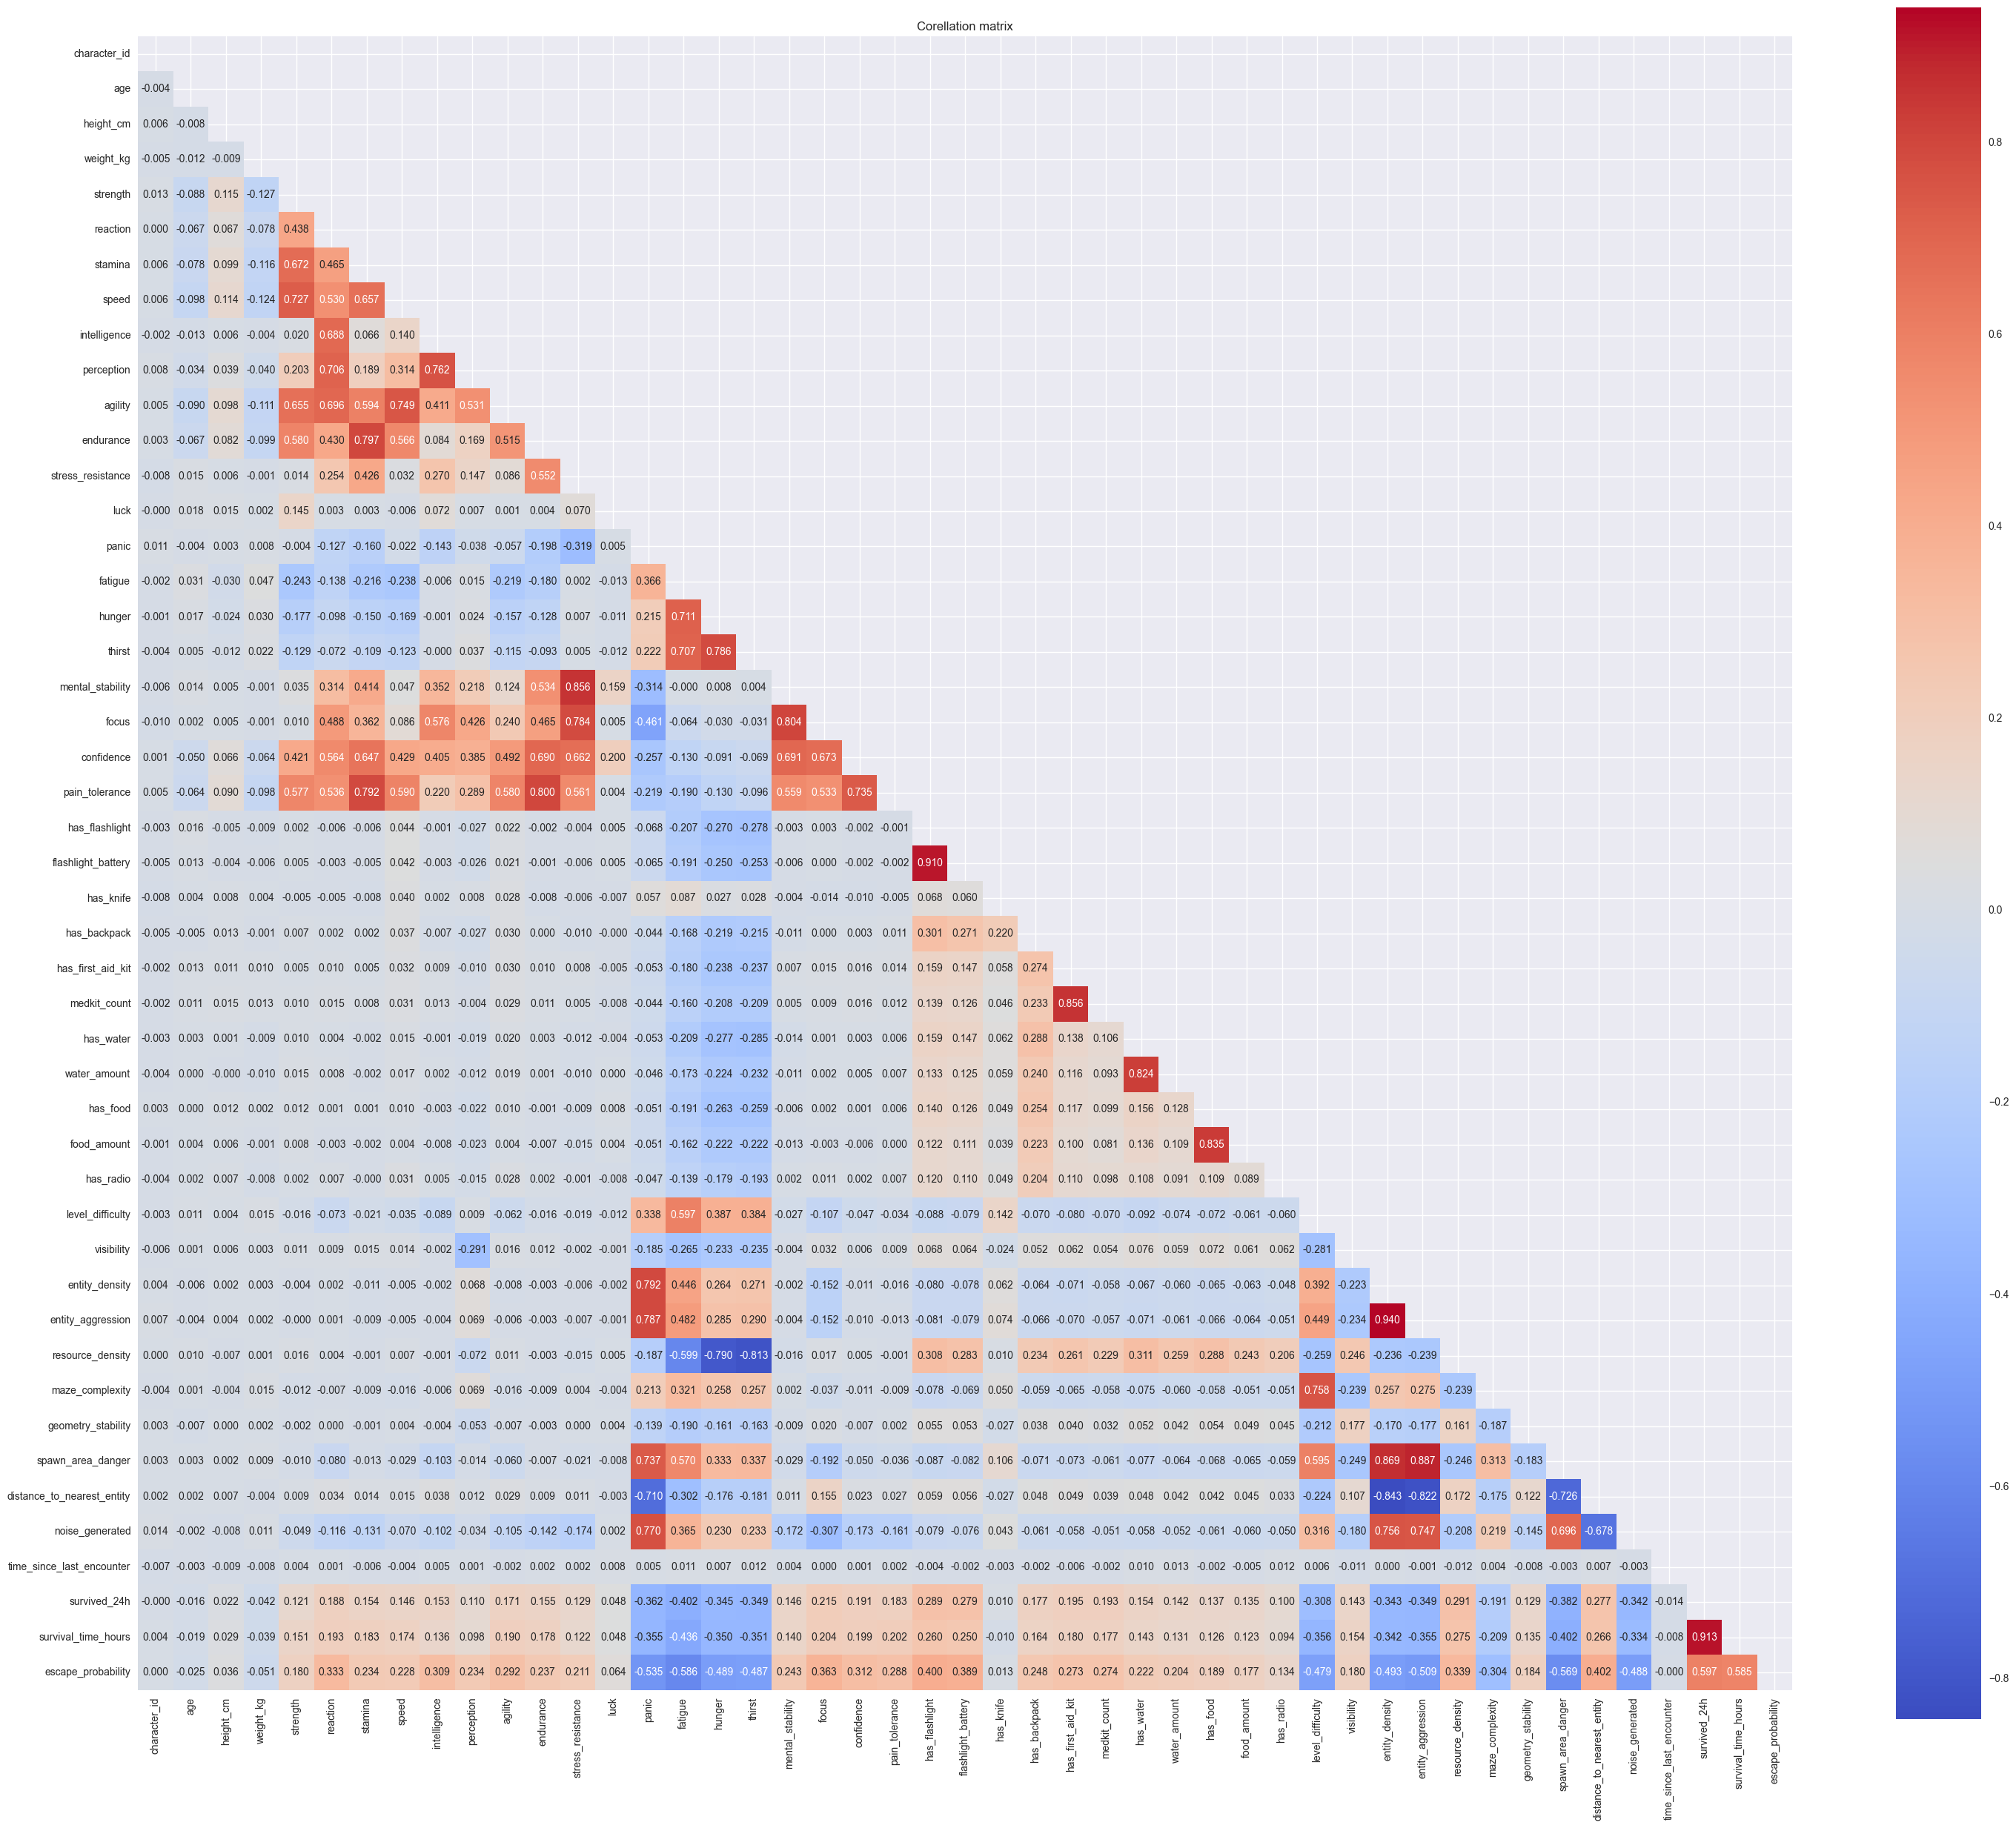

In [13]:
mask = np.triu(np.ones_like(df[numerical].corr(), dtype=bool))

plt.figure(figsize=(36, 30))
sns.heatmap(df[numerical].corr(), mask=mask, cmap='coolwarm', square=True, annot=True, fmt='.3f')
# sns.heatmap(df[numerical].corr(), cmap='coolwarm', fmt='.2f', square=True)
plt.title('Corellation matrix')
plt.show()

# Feature engineering

In [14]:
df = pd.get_dummies(df, columns=['sex', 'level_id', 'special_rule'], drop_first=True)
df = df.replace({True: 1, False: 0})
df.head()

/var/folders/xw/1ypq_4cx13v57g2x9gtl5bz80000gn/T/ipykernel_9390/3666033135.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


,character_id,age,height_cm,weight_kg,strength,reaction,stamina,speed,intelligence,perception,...,level_id_7,level_id_8,level_id_end,special_rule_darkness,special_rule_flooding,special_rule_haunted_hotel,special_rule_liminal_office,special_rule_mechanical_noise,special_rule_neutral,special_rule_trap_exit
0,1,33,170,90,6,5,5,4,6,7,...,0,0,0,0,0,1,0,0,0,0
1,2,39,166,39,2,3,4,4,5,4,...,0,0,0,1,0,0,0,0,0,0
2,3,25,158,77,3,3,4,3,2,1,...,0,0,0,0,0,0,1,0,0,0
3,4,76,188,58,5,5,6,6,3,4,...,0,1,0,0,0,0,0,0,0,0
4,5,73,155,56,5,4,3,4,5,5,...,0,0,0,0,0,1,0,0,0,0


In [15]:
# df = df.drop(['spawn_area_danger', 'focus', 'pain_tolerance'], axis=1)
df = df.drop(['character_id'], axis=1)

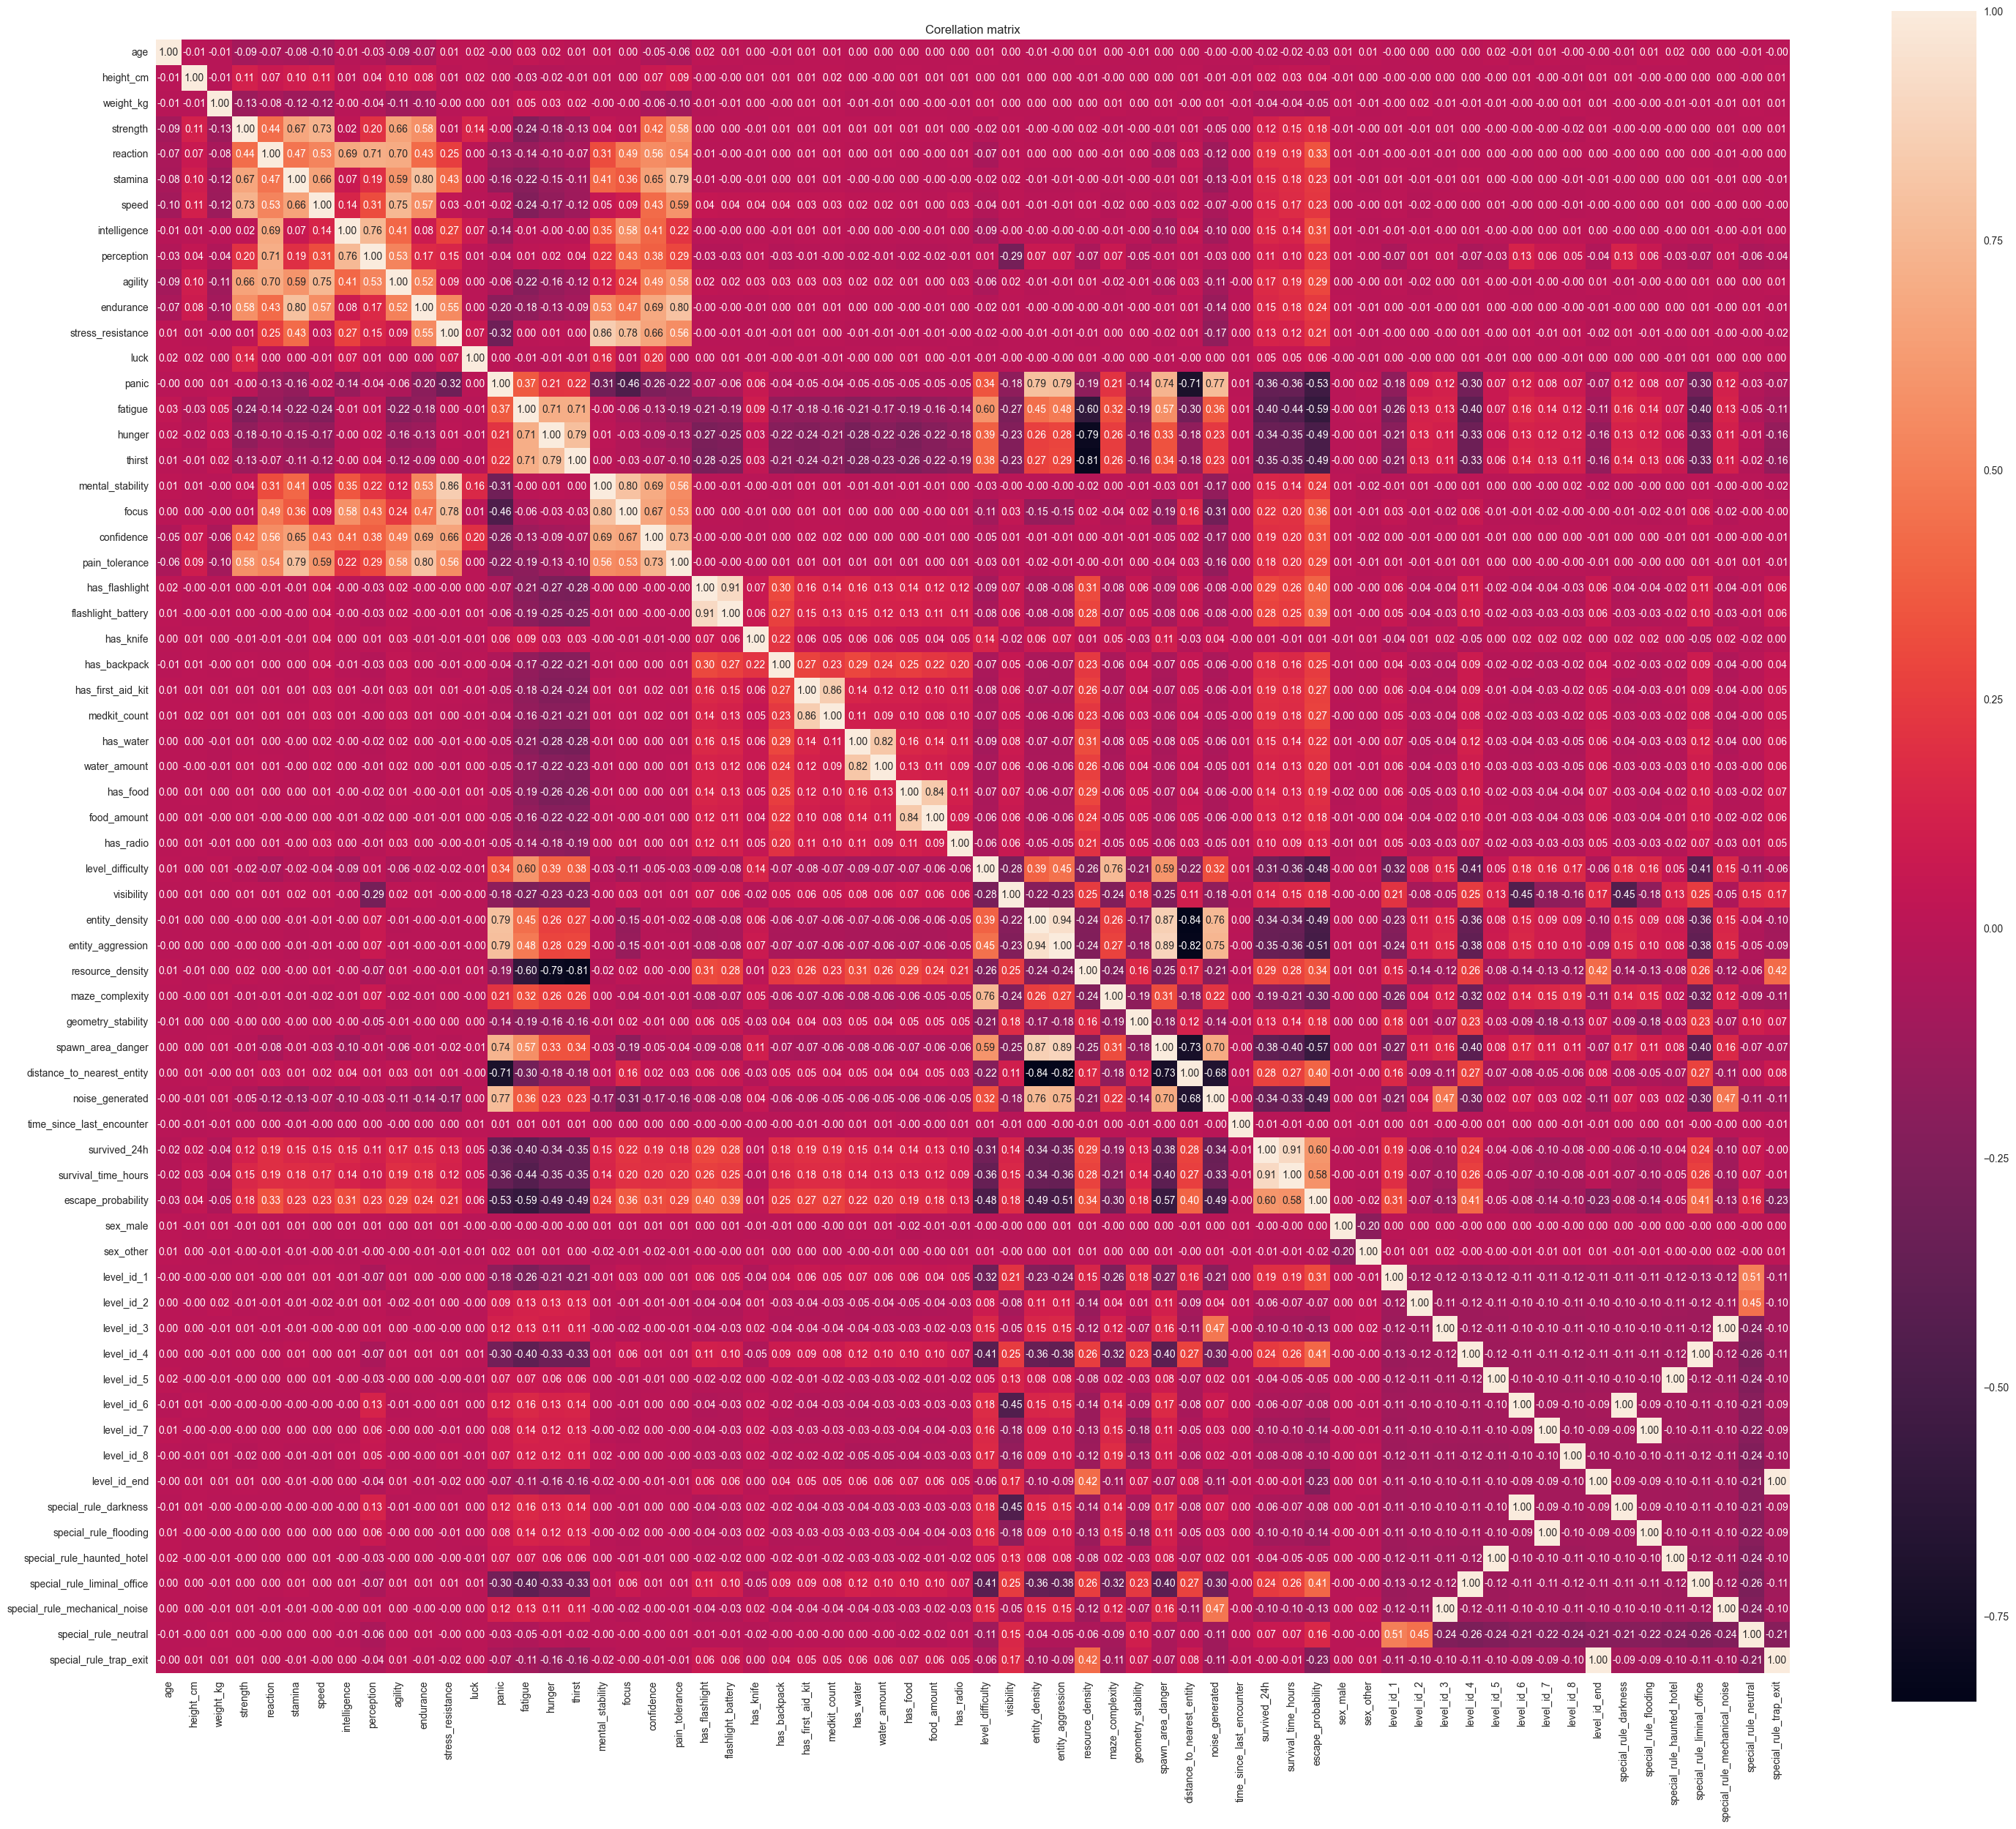

In [16]:
plt.figure(figsize=(36, 30))
sns.heatmap(df.corr(), square=True, annot=True, fmt='.2f')
plt.title('Corellation matrix')
plt.show()

# Saving

In [17]:
df.to_parquet('../data/processed/backrooms_processed.parquet', index=False)
print('parquet-file has been saved into data/processed')

parquet-file has been saved into data/processed
